<center>
    <font size="5"> Sieci neuronowe i uczenie głębokie<br/>
        <small><em>Studia stacjonarne II stopnia 2025/2026</em><br/>Kierunek: Matematyka stosowana<br>Specjalność: Analityka danych</small>
    </font>
</center>
<br>

# Laboratorium nr 3: Sztuczne Sieci Neuronowe - wprowadzenie do bibliotek TensorFlow i Keras

### Sieci neuronowe w języku Python
Obecnie za sprawą rozwoju i popularności tzw. głębokich sieci neuronowych (Deep Neural Network) dostępnych jest bardzo dużo bibliotek/frameworków do budowy i uczenia sieci neuronowych (TensorFlow, Theano, Spark MLlib, MXNet, Microsoft Cognitive Toolkit, Caffe itp.). Z wielu z nich można korzystać w prosty sposób przy wykorzystaniu języka Python.

### Biblioteka [TensorFlow](https://www.tensorflow.org/)
TensorFlow – otwartoźródłowa biblioteka programistyczna napisana przez Google Brain Team. Wykorzystywana w uczeniu maszynowym i głębokich sieciach neuronowych. Biblioteka może do działania wykorzystywać zarówno karty graficzne, procesory (m.in. dla urządzeń mobilnych oraz systemów wbudowanych), jak i wyspecjalizowane mikroprocesory nazywane akceleratorami AI – tensor processing unit. Biblioteka składa się z kilku modułów. W jej najniższej warstwie znajduje się rozproszony silnik wykonawczy (ang. distributed execution engine), który w celu podniesienia wydajności został zaimplementowany w języku programowania C++. Nad nią znajdują się frontendy napisane w kilku językach programowania m.in. w Pythonie oraz C++. Powyżej umieszczona została warstwa API, która zapewnia prostszy interfejs dla powszechnie używanych warstw w modelach głębokiego uczenia. Na następną warstwę składają się wysokopoziomowe API, m.in. Keras oraz Estimator API, które ułatwiają tworzenie modeli i ich ocenę. Ponad tym znajdują się przygotowane przez twórców biblioteki gotowe do użycia modele. [Wikipedia](https://pl.wikipedia.org/wiki/TensorFlow)

### Biblioteka [Keras](https://keras.io/)
Keras jest wysokopoziomową nakładką na biblioteki takie jak TensorFlow, CNTK (Microsoft Cognitive Toolkit) lub Theano napisaną w języku Python. Domyślnie wykorzystywanym backendem jest TensorFlow i z takiego będziemy korzystać.  

Biblioteka ta pozwala na:
*   Łatwe i szybkie prototypowanie modeli (pełna modularność).
*   Wspiera zarówno "klasyczne" sieci neuronowe jak i konwolucyjne czy rekurencyjne.
*   Umożliwia uczenie przy wykorzystaniu CPU oraz GPU.

Aktualnie biblioteka Keras dostępna jest również jako podmoduł biblioteki TensorFlow.  

### Import bibliotek

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

print("Numpy version:", np.__version__)
print("Tensorflow version:", tf.__version__)

2026-03-09 23:45:14.907233: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Numpy version: 2.4.2
Tensorflow version: 2.20.0


### Graf obliczeniowy
Biblioteka Tensorflow reprezentuje obliczenia za pomocą grafów (drzew)obliczeniowych, gdzie w węzłach terminalnych (liściach) znajdują się dane (tensory) a w pozostałych węzłach operacje matematyczne.

Prosty przykład:

![graph](http://torus.uck.pk.edu.pl/~amarsz/images/zmum/graph.PNG)

In [2]:
# dane wejściowe
a = tf.constant(15, name="a")
b = tf.constant(61, name="b")

# dodawanie
c = tf.add(a, b, name="c")
c

I0000 00:00:1773096321.020330    6114 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4078 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1660 Ti, pci bus id: 0000:01:00.0, compute capability: 7.5


<tf.Tensor: shape=(), dtype=int32, numpy=76>

TensorFlow nie wykonuje obliczeń od razu, tworzy graf, który należy później wykonań. W tym celu w wersji 1.x należało zainicjować wszystkie zmienne i uruchomić sesję. W wersji 2.x jest dużo prościej.

In [3]:
c.numpy()

np.int32(76)

#### Ćwiczenie 1: Perceptron
Stwórz model perceptronu z wykorzystaniem biblioteki TensorFlow.

![perceptron](http://torus.uck.pk.edu.pl/~amarsz/images/zmum/neuron2.PNG)![eq](http://torus.uck.pk.edu.pl/~amarsz/images/zmum/n2eq2.PNG)

In [4]:
n_in = 2  # liczba sygnałów wejściowych
W = tf.Variable(tf.ones((n_in, 1)))  # tf.random_uniform()
b = tf.Variable(tf.zeros((1, 1)))


def perceptron(x, W, b):
    y = tf.sigmoid(tf.matmul(x, W) + b)
    return y

In [5]:
x_input = tf.constant([[1, 2.0]], shape=(1, 2))
model = perceptron(x_input, W, b)
y_out = model.numpy()
print(y_out)

[[0.95257413]]


### Sieć wielowarstwowa z wykorzystanie biblioteki Keras

In [6]:
from tensorflow import keras
from tensorflow.keras import Model, Sequential
from tensorflow.keras.layers import Dense, Input

In [7]:
!python -c "import sys; print(sys.executable)"

/home/qertal/miniconda3/envs/python312/bin/python


In [8]:
mlp = Sequential()
mlp.add(Dense(1, activation="sigmoid", kernel_initializer="ones", input_shape=(2,)))

/home/qertal/miniconda3/envs/python312/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
mlp.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3 (12.00 B)

 Trainable params: 3 (12.00 B)

 Non-trainable params: 0 (0.00 B)

In [10]:
mlp.predict(np.array([[2, 1]]))

2026-03-09 23:45:24.070187: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f8da40037b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-09 23:45:24.070245: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce GTX 1660 Ti, Compute Capability 7.5
2026-03-09 23:45:24.107143: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-09 23:45:24.192133: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 553ms/step


I0000 00:00:1773096324.450554   21732 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


array([[0.95257413]], dtype=float32)

Prosty przykład (Perceptron)

In [11]:
def mlp(n_in, n_out):
    x = Input(shape=(n_in,))
    y = Dense(n_out, activation="sigmoid", kernel_initializer="ones")(x)
    return Model(inputs=x, outputs=y)


model = mlp(2, 1)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3 (12.00 B)

 Trainable params: 3 (12.00 B)

 Non-trainable params: 0 (0.00 B)

In [12]:
x_input = tf.constant([[1, 2.0]], shape=(1, 2))

In [13]:
y_out = model.predict(x_input)
print(y_out)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step
[[0.95257413]]


### Ćwiczenie 2: Zamodeluj i wytrenuj sieć dla problemu XOR


In [14]:
xx = np.array([[-1, -1], [1, -1], [-1, 1], [1, 1]])
d = np.array([0, 1, 1, 0])


def mlp(n_in, n_hidden, n_out):
    x = Input(shape=(n_in,))
    h = Dense(n_hidden, activation="relu")(x)
    y = Dense(n_out, activation="sigmoid")(h)
    model = Model(inputs=x, outputs=y)
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model


model = mlp(2, 1, 1)
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5 (20.00 B)

 Trainable params: 5 (20.00 B)

 Non-trainable params: 0 (0.00 B)

In [15]:
model.compile(loss="mse", optimizer="adam", metrics=["accuracy"])

In [16]:
hist = model.fit(xx, d, epochs=1000, batch_size=4, verbose=1)
pred = model.predict(xx)

Epoch 1/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.5000 - loss: 0.2456
Epoch 2/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.5000 - loss: 0.2454
Epoch 3/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.5000 - loss: 0.2453
Epoch 4/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.5000 - loss: 0.2451
Epoch 5/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.5000 - loss: 0.2450
Epoch 6/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.5000 - loss: 0.2448
Epoch 7/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.5000 - loss: 0.2447
Epoch 8/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.5000 - loss: 0.2445
Epoch 9/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.5000 - loss: 0.2444
Epoch 10/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.5000 - loss: 0.2442
Epoch 11/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.5000 - loss: 0.2441
Epoch 12/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0

In [17]:
model.predict(xx)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


array([[0.35825723],
       [0.895154  ],
       [0.35825723],
       [0.35825723]], dtype=float32)

### Przykład trenowania sieci - Aproksymacja funkcji

#### Przygotowanie danych

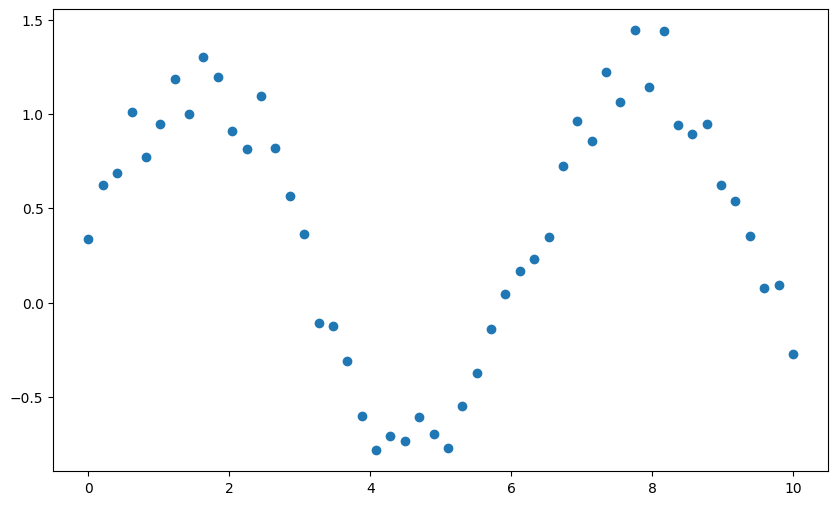

In [18]:
data_x = np.linspace(0, 10, 50)
data_y = np.sin(data_x) + np.random.random(data_x.shape[0]) * 0.5
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(data_x, data_y, "o")
plt.show()

#### Podział na dane uczące i walidacyjne.

Dane walidacyjne służą do monitorowania procesu uczenia, sprawdzania jak sieć radzi sobie z danymi, które nie są wykorzystywane do modyfikacji wag.

Jeśli błąd na danych uczących maleje, a na danych walidacyjnych już nie (lub wręcz rośnie), jest to potencjalny sygnał, że sieć jest przeczuczona.

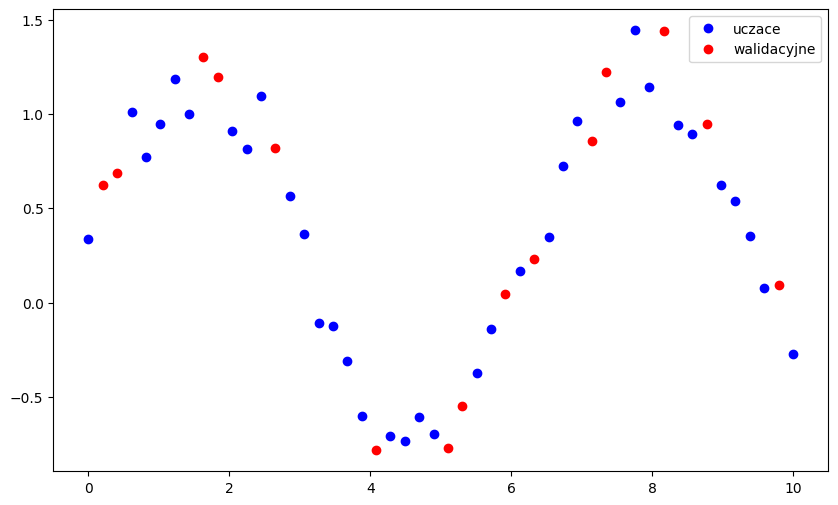

In [19]:
temp = np.arange(50)
np.random.shuffle(temp)
val_x = data_x[temp[35:]]
val_y = data_y[temp[35:]]
data_x = data_x[temp[:35]]
data_y = data_y[temp[:35]]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(data_x, data_y, "bo", label="uczace")
ax.plot(val_x, val_y, "ro", label="walidacyjne")
ax.legend()
plt.show()

#### Mała sieć, 35 neuronów w jednej warstwie ukrytej.

In [20]:
def mlp(n_in, n_h):
    x = Input(shape=(n_in,))
    h = Dense(n_h, activation="tanh")(x)
    y = Dense(1, activation="linear")(h)
    return Model(inputs=x, outputs=y)


model1 = mlp(1, 35)
model1.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 35)             │            70 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            36 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 106 (424.00 B)

 Trainable params: 106 (424.00 B)

 Non-trainable params: 0 (0.00 B)

In [21]:
model1.compile(loss="mse", optimizer="adam")
hist = model1.fit(
    data_x, data_y, epochs=100, verbose=1, batch_size=35, validation_data=(val_x, val_y)
)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 1.9833 - val_loss: 2.2078
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - loss: 1.8798 - val_loss: 2.1021
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - loss: 1.7799 - val_loss: 2.0001
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - loss: 1.6837 - val_loss: 1.9016
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - loss: 1.5911 - val_loss: 1.8069
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step - loss: 1.5022 - val_loss: 1.7159
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - loss: 1.4171 - val_loss: 1.6287
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - loss: 1.3359 - val_loss: 1.5454
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - loss: 1.2584 - val_loss: 1.4658
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - loss: 1.1848 - val_loss: 1.3901
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - loss: 1.1150 - val_loss: 1.3182
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - loss: 1.0490

1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/stepWARNING:tensorflow:5 out of the last 8 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x7f8f6a45aac0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


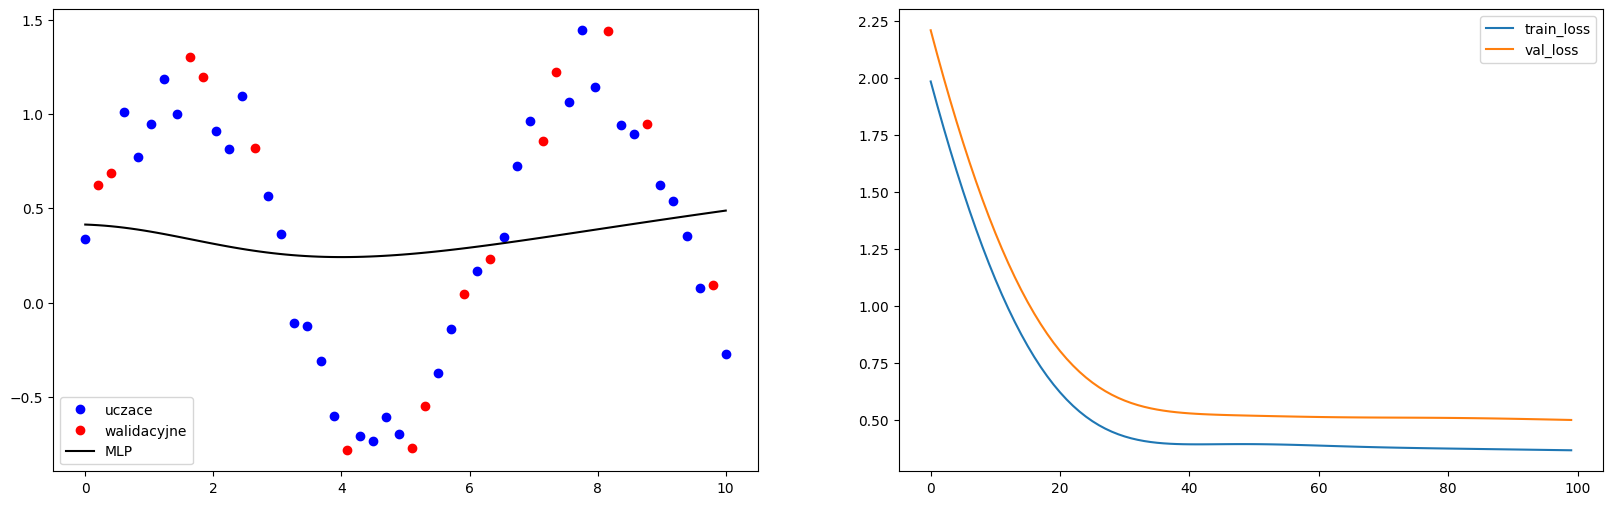

In [22]:
data_xx = np.linspace(0, 10, 100)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))
ax1.plot(data_x, data_y, "bo", label="uczace")
ax1.plot(val_x, val_y, "ro", label="walidacyjne")
pred = model1.predict(data_xx)
ax1.plot(data_xx, pred, "k-", label="MLP")
ax1.legend()
ax2.plot(hist.history["loss"], label="train_loss")
ax2.plot(hist.history["val_loss"], label="val_loss")
ax2.legend()
plt.show()

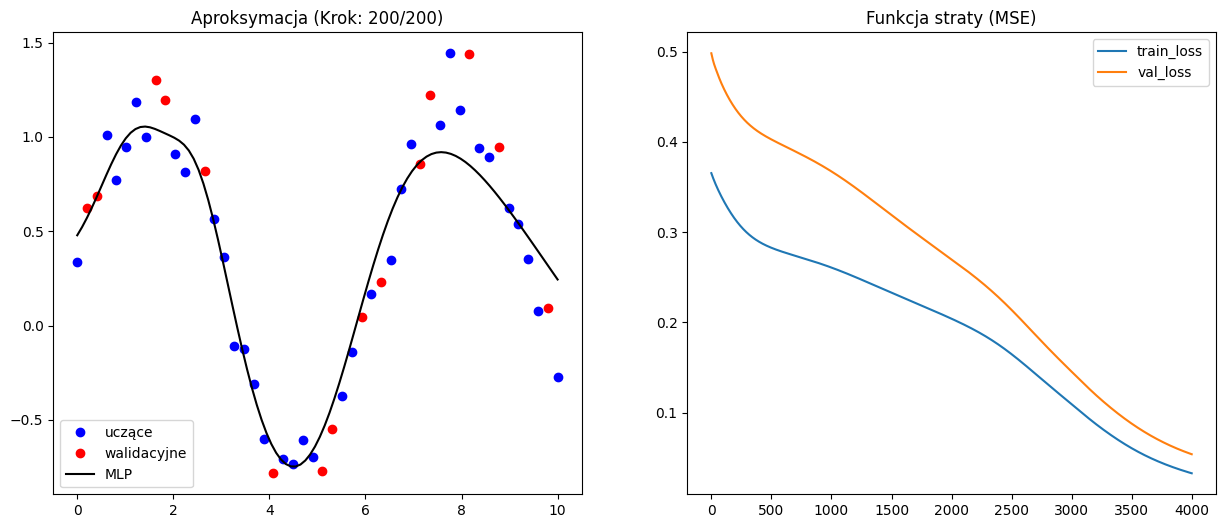

In [23]:
from IPython.display import clear_output

model = model1
# model.reset_states()

train_loss = []
val_loss = []

for i in range(200):
    # Douczanie modelu przez 20 epok (verbose=0 wycisza logi tekstowe)
    hist = model.fit(
        data_x,
        data_y,
        epochs=20,
        verbose=0,
        batch_size=35,
        validation_data=(val_x, val_y),
    )

    train_loss.extend(hist.history["loss"])
    val_loss.extend(hist.history["val_loss"])

    pred = model.predict(data_xx, verbose=0)

    clear_output(wait=True)

    # Rysowanie nowego stanu
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # Lewy wykres: Punkty i aproksymacja
    ax1.plot(data_x, data_y, "bo", label="uczące")
    ax1.plot(val_x, val_y, "ro", label="walidacyjne")
    ax1.plot(data_xx, pred, "k-", label="MLP")
    ax1.set_title(f"Aproksymacja (Krok: {i+1}/200)")
    ax1.legend()

    # Prawy wykres: Krzywa uczenia (funkcja straty)
    ax2.plot(train_loss, label="train_loss")
    ax2.plot(val_loss, label="val_loss")
    ax2.set_title("Funkcja straty (MSE)")
    ax2.legend()

    plt.show()

#### Większa sieć, dwie warstwy ukryte.

In [24]:
def mlp2(n_in, n_h1, n_h2):
    x = Input(shape=(n_in,))
    h1 = Dense(n_h1, activation="tanh")(x)
    h2 = Dense(n_h2, activation="tanh")(h1)
    y = Dense(1, activation="linear")(h2)
    return Model(inputs=x, outputs=y)


model2 = mlp2(1, 500, 100)
model2.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 500)            │         1,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 100)            │        50,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,201 (200.00 KB)

 Trainable params: 51,201 (200.00 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
model2.compile(loss="mse", optimizer="adam")

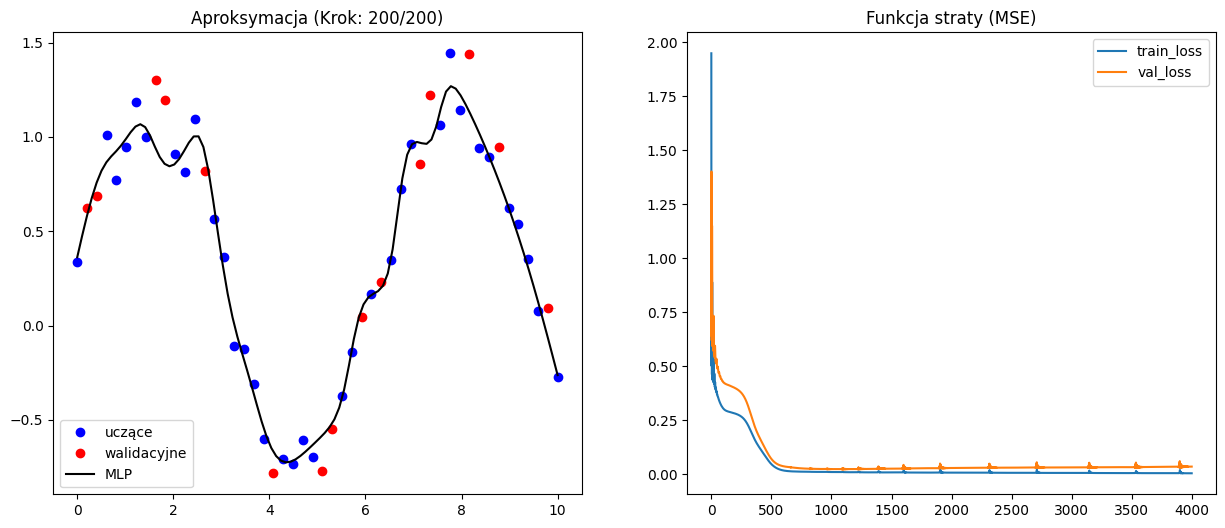

In [26]:
model = model2
# model.reset_states()

train_loss = []
val_loss = []

for i in range(200):
    # Douczanie modelu przez 20 epok (verbose=0 wycisza logi tekstowe)
    hist = model.fit(
        data_x,
        data_y,
        epochs=20,
        verbose=0,
        batch_size=35,
        validation_data=(val_x, val_y),
    )

    train_loss.extend(hist.history["loss"])
    val_loss.extend(hist.history["val_loss"])

    pred = model.predict(data_xx, verbose=0)

    clear_output(wait=True)

    # Rysowanie nowego stanu
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # Lewy wykres: Punkty i aproksymacja
    ax1.plot(data_x, data_y, "bo", label="uczące")
    ax1.plot(val_x, val_y, "ro", label="walidacyjne")
    ax1.plot(data_xx, pred, "k-", label="MLP")
    ax1.set_title(f"Aproksymacja (Krok: {i+1}/200)")
    ax1.legend()

    # Prawy wykres: Krzywa uczenia (funkcja straty)
    ax2.plot(train_loss, label="train_loss")
    ax2.plot(val_loss, label="val_loss")
    ax2.set_title("Funkcja straty (MSE)")
    ax2.legend()

    plt.show()

### Ćwiczenie 3: Znajdź najlepszą architekturę sieci MLP, wykorzystaj techniki regularyzacji.

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, callbacks

(x_train_full, y_train_full), (x_test_full, y_test_full) = (
    tf.keras.datasets.mnist.load_data()
)

train_mask = np.logical_or(y_train_full == 2, y_train_full == 7)
test_mask = np.logical_or(y_test_full == 2, y_test_full == 7)

x_train = x_train_full[train_mask]
y_train = y_train_full[train_mask]
x_test = x_test_full[test_mask]
y_test = y_test_full[test_mask]

# Zamiana etykiet:
# 2 -> 0
# 7 -> 1
y_train = np.where(y_train == 2, 0, 1)
y_test = np.where(y_test == 2, 0, 1)

# normalizacja
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = x_train.reshape(-1, 28 * 28)
x_test = x_test.reshape(-1, 28 * 28)

# podzial
val_size = int(0.2 * len(x_train))

x_val = x_train[:val_size]
y_val = y_train[:val_size]

x_train = x_train[val_size:]
y_train = y_train[val_size:]

print("Liczba przykładów treningowych:", len(x_train))
print("Liczba przykładów walidacyjnych:", len(x_val))
print("Liczba przykładów testowych:", len(x_test))


# func do tworzenia modelu
def create_model(hidden_layers, dropout_rate=0.2, l2_value=0.001):
    model = models.Sequential()
    model.add(layers.Input(shape=(784,)))

    for units in hidden_layers:
        model.add(
            layers.Dense(
                units, activation="relu", kernel_regularizer=regularizers.l2(l2_value)
            )
        )
        model.add(layers.Dropout(dropout_rate))

    model.add(layers.Dense(1, activation="sigmoid"))

    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

    return model


# lsoowe architektury do przetestowania
architectures = [[32], [64], [128], [64, 32], [128, 64], [128, 64, 32]]

results = []

early_stop = callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)

# trenowanie modeli i porównanie wyników
for arch in architectures:
    print(f"\nTrenowanie modelu o architekturze: {arch}")

    model = create_model(hidden_layers=arch, dropout_rate=0.2, l2_value=0.001)

    history = model.fit(
        x_train,
        y_train,
        validation_data=(x_val, y_val),
        epochs=30,
        batch_size=32,
        callbacks=[early_stop],
        verbose=0,
    )

    val_loss, val_acc = model.evaluate(x_val, y_val, verbose=0)
    print(f"Dokładność na zbiorze walidacyjnym: {val_acc:.4f}")

    results.append((arch, val_acc, model))

# bets model
best_arch, best_val_acc, best_model = max(results, key=lambda x: x[1])

print("\nNajlepsza architektura:", best_arch)
print(f"Najlepsza dokładność walidacyjna: {best_val_acc:.4f}")

test_loss, test_acc = best_model.evaluate(x_test, y_test, verbose=0)
print(f"Dokładność na zbiorze testowym: {test_acc:.4f}")

Liczba przykładów treningowych: 9779
Liczba przykładów walidacyjnych: 2444
Liczba przykładów testowych: 2060

Trenowanie modelu o architekturze: [32]
Dokładność na zbiorze walidacyjnym: 0.9959

Trenowanie modelu o architekturze: [64]
Dokładność na zbiorze walidacyjnym: 0.9894

Trenowanie modelu o architekturze: [128]
Dokładność na zbiorze walidacyjnym: 0.9930

Trenowanie modelu o architekturze: [64, 32]
Dokładność na zbiorze walidacyjnym: 0.9914

Trenowanie modelu o architekturze: [128, 64]
Dokładność na zbiorze walidacyjnym: 0.9890

Trenowanie modelu o architekturze: [128, 64, 32]
Dokładność na zbiorze walidacyjnym: 0.9914

Najlepsza architektura: [32]
Najlepsza dokładność walidacyjna: 0.9959
Dokładność na zbiorze testowym: 0.9903
